In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
%matplotlib inline

| Feature   | Description                                                                                     |
|-----------|-------------------------------------------------------------------------------------------------|
| Age       | Age of the patient                                                                               |
| Sex       | Sex of the patient (1 = male, 0 = female)                                                       |
| exang     | Exercise induced angina (1 = yes; 0 = no)                                                      |
| ca        | Number of major vessels (0-3)                                                                  |
| cp        | Chest pain type:                                                                                |
|           | - 0: typical angina                                                                             |
|           | - 1: atypical angina                                                                            |
|           | - 2: non-anginal pain                                                                           |
|           | - 3: asymptomatic                                                                               |
| trtbps    | Resting blood pressure (in mm Hg)                                                              |
| chol      | Cholesterol in mg/dl (via BMI sensor)                                                          |
| fbs       | Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)                                         |
| restecg   | Resting electrocardiographic results:                                                         |
|           | - 0: normal                                                                                     |
|           | - 1: ST-T wave abnormality (T wave inversions / ST elevation or depression > 0.05 mV)         |
|           | - 2: probable or definite left ventricular hypertrophy by Estes' criteria                      |
| thalachh  | Maximum heart rate achieved                                                                     |
| exng      | Exercise induced angina (1 = yes; 0 = no)                                                     |
| oldpeak   | ST depression induced by exercise relative to rest                                              |
| slp       | Slope of the peak exercise ST segment                                                          |
| caa       | Number of major vessels colored by fluoroscopy                                                 |
| thall     | Thalassemia:                                                                                    |
|           | - 1 = normal                                                                                    |
|           | - 2 = fixed defect                                                                               |
|           | - 3 = reversable defect                                                                          |
| output    | Target: 0 = less chance of heart attack, 1 = more chance of heart attack                        |


In [2]:
df=pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.shape

(303, 14)

In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


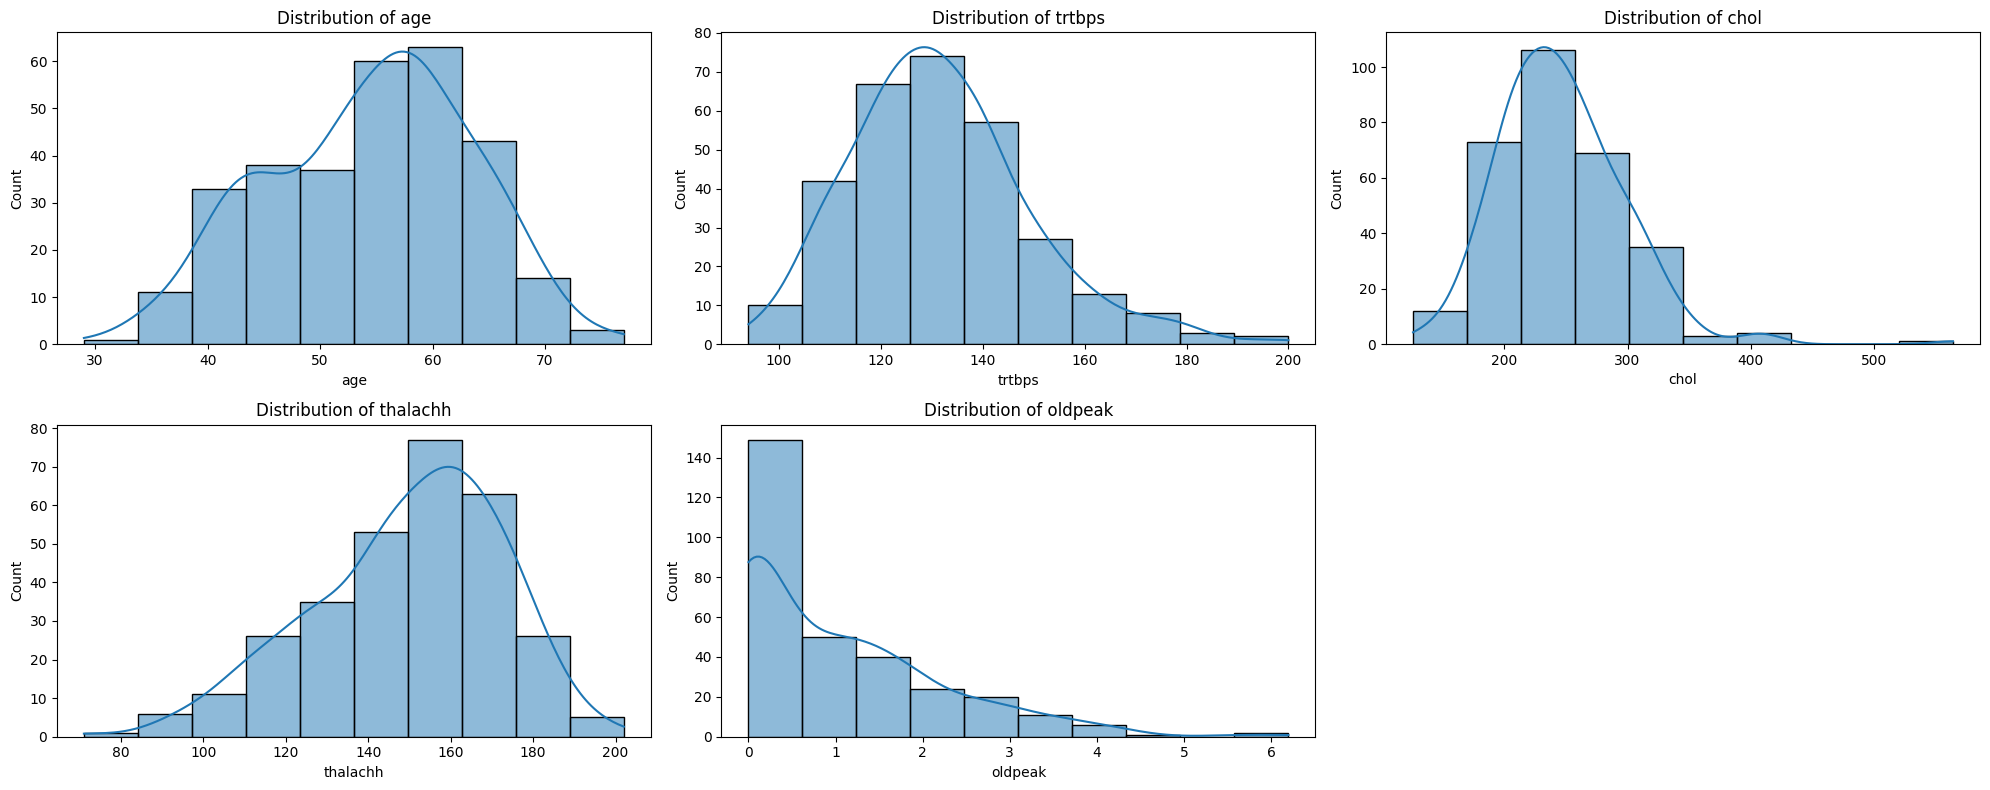

In [9]:
numerical_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa', 'thall', 'output']

# 1. Univariate Visualizations: Histograms for numerical variables
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=10, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
if len(numerical_cols) < len(axes):
    fig.delaxes(axes[-1])  
plt.tight_layout()
plt.show()

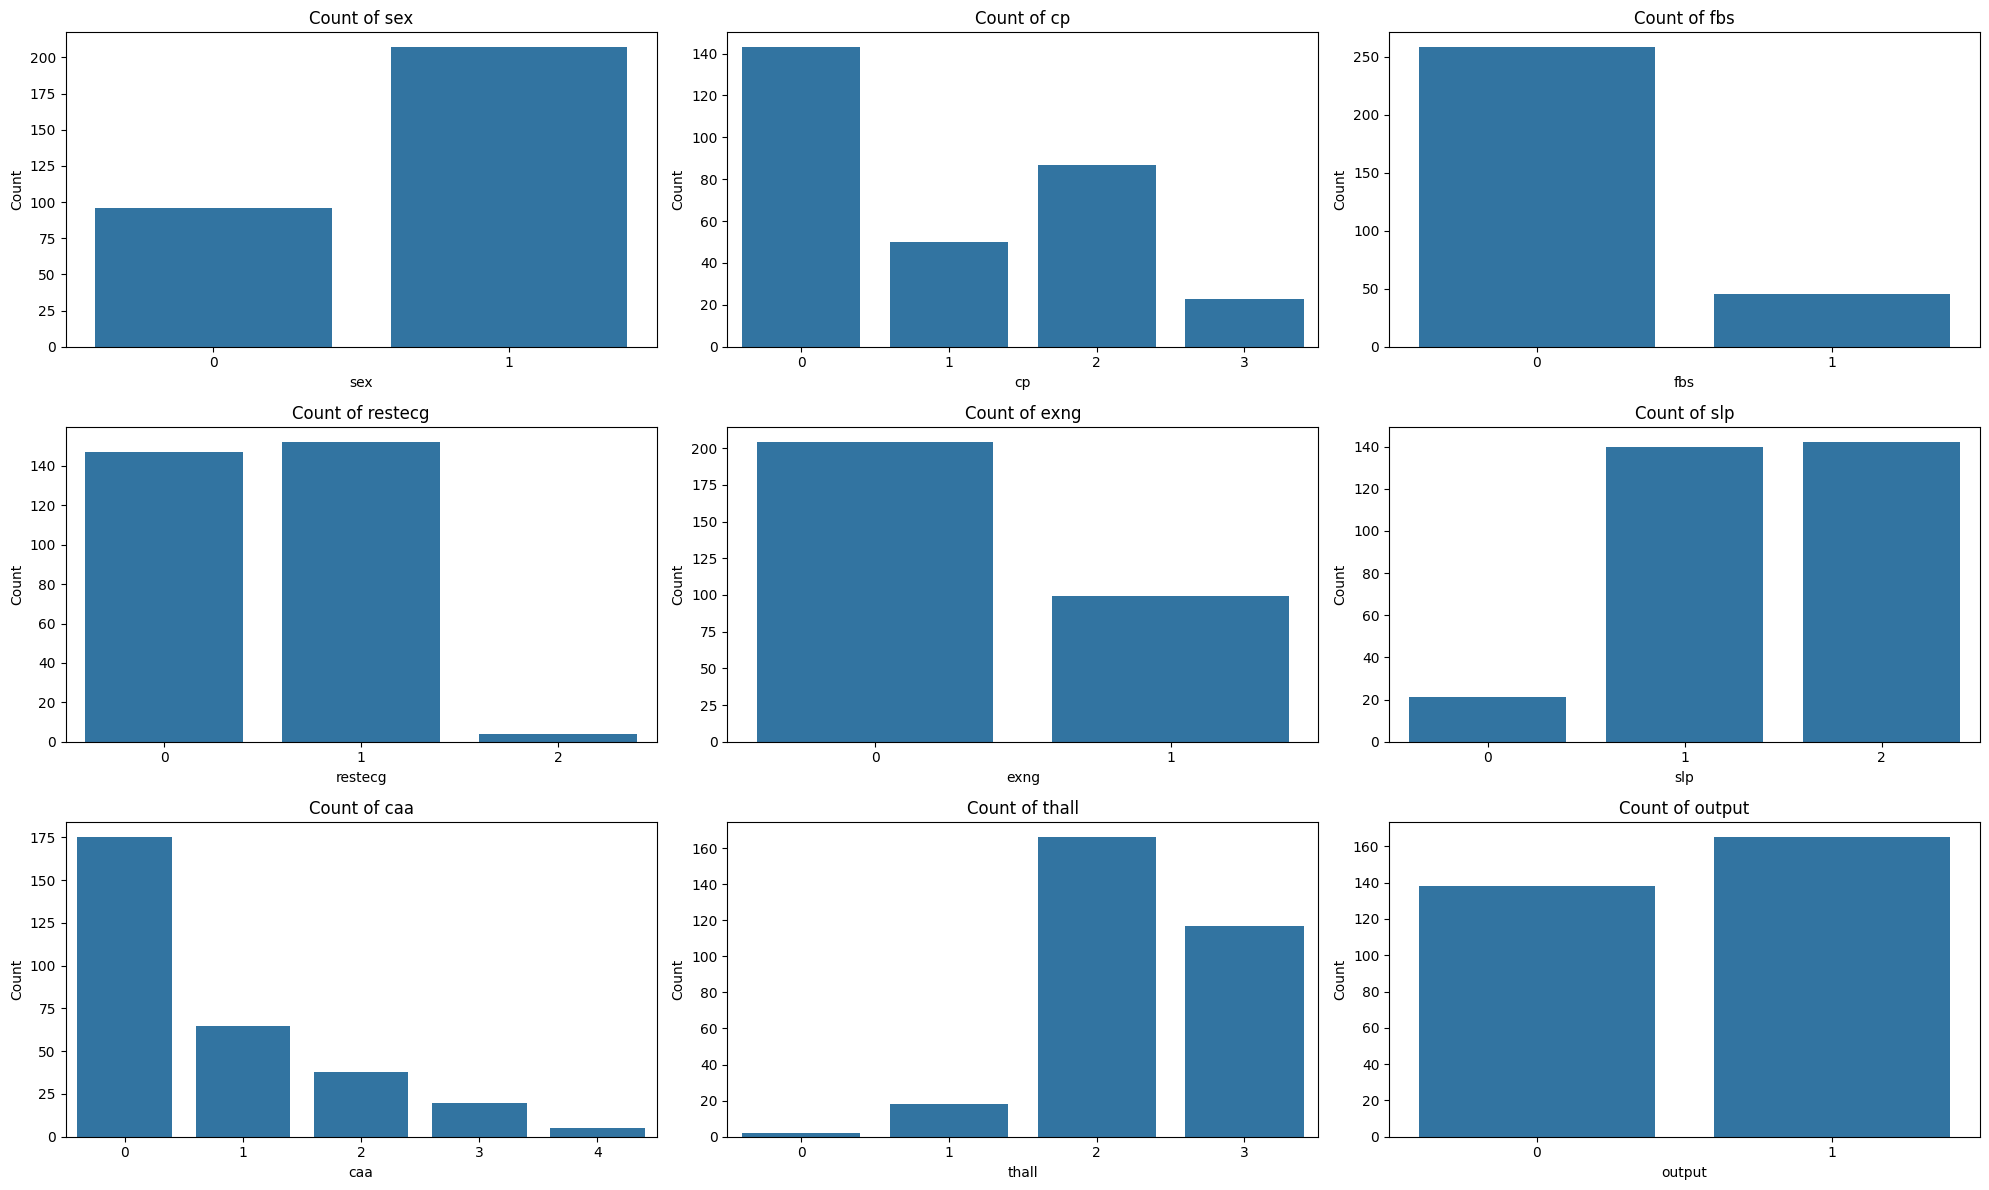

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove empty subplots
plt.tight_layout()
plt.show()

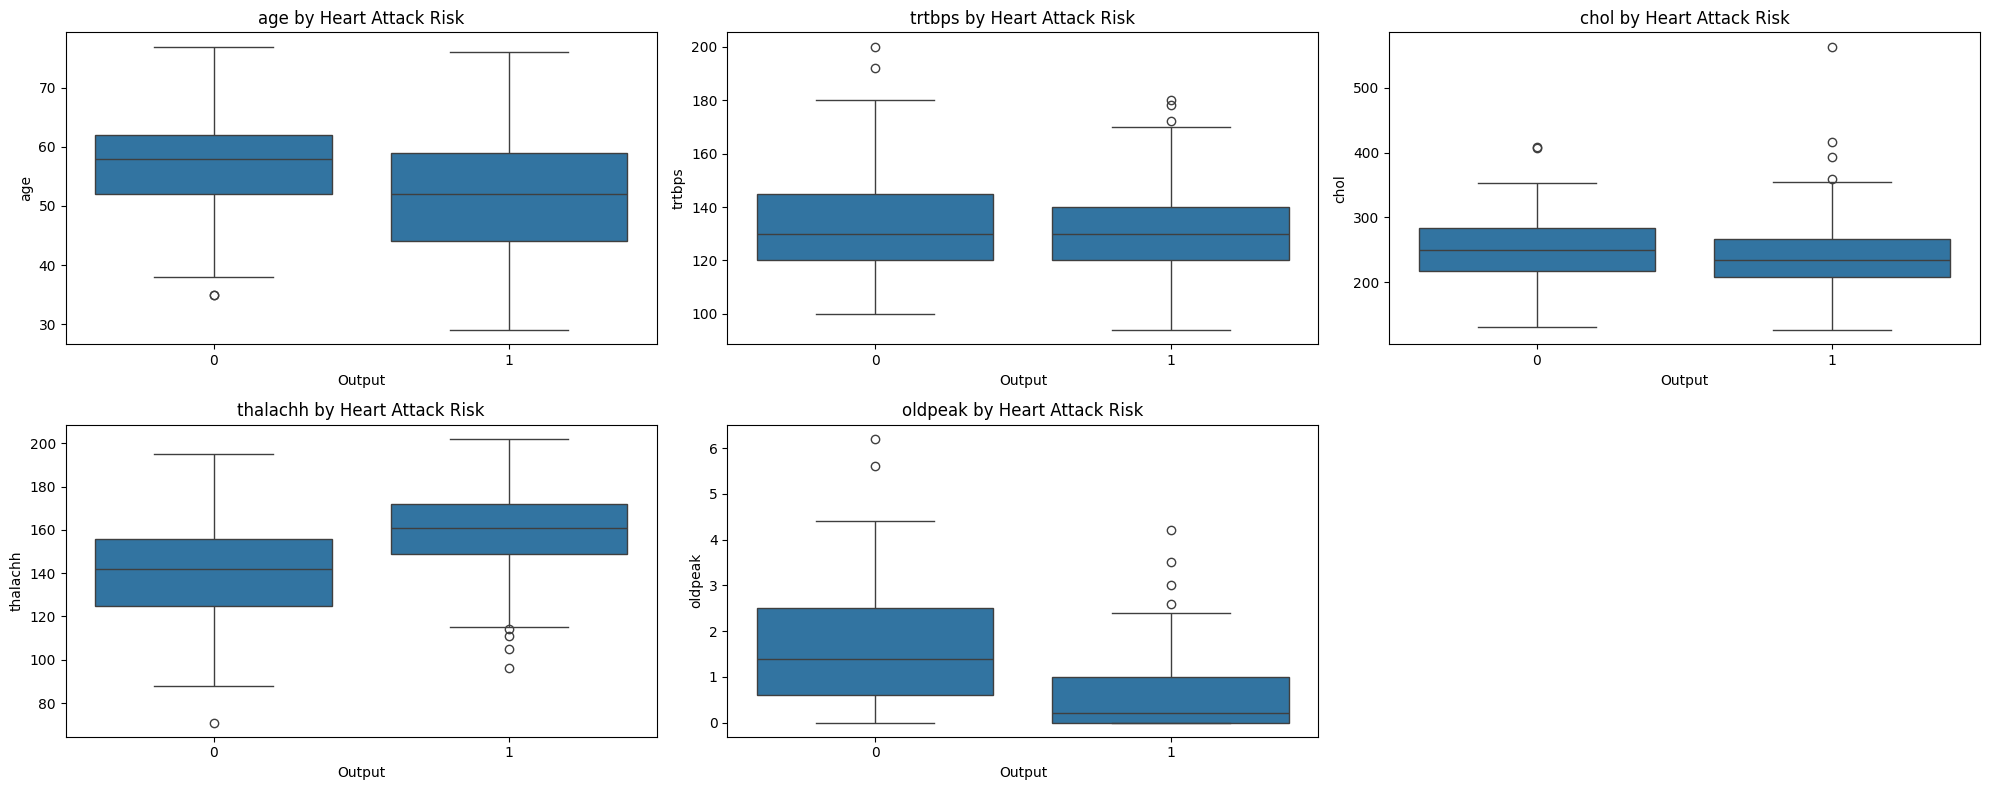

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(x='output', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by Heart Attack Risk')
    axes[i].set_xlabel('Output')
    axes[i].set_ylabel(col)
if len(numerical_cols) < len(axes):
    fig.delaxes(axes[-1])  # Remove empty subplot
plt.tight_layout()
plt.show()

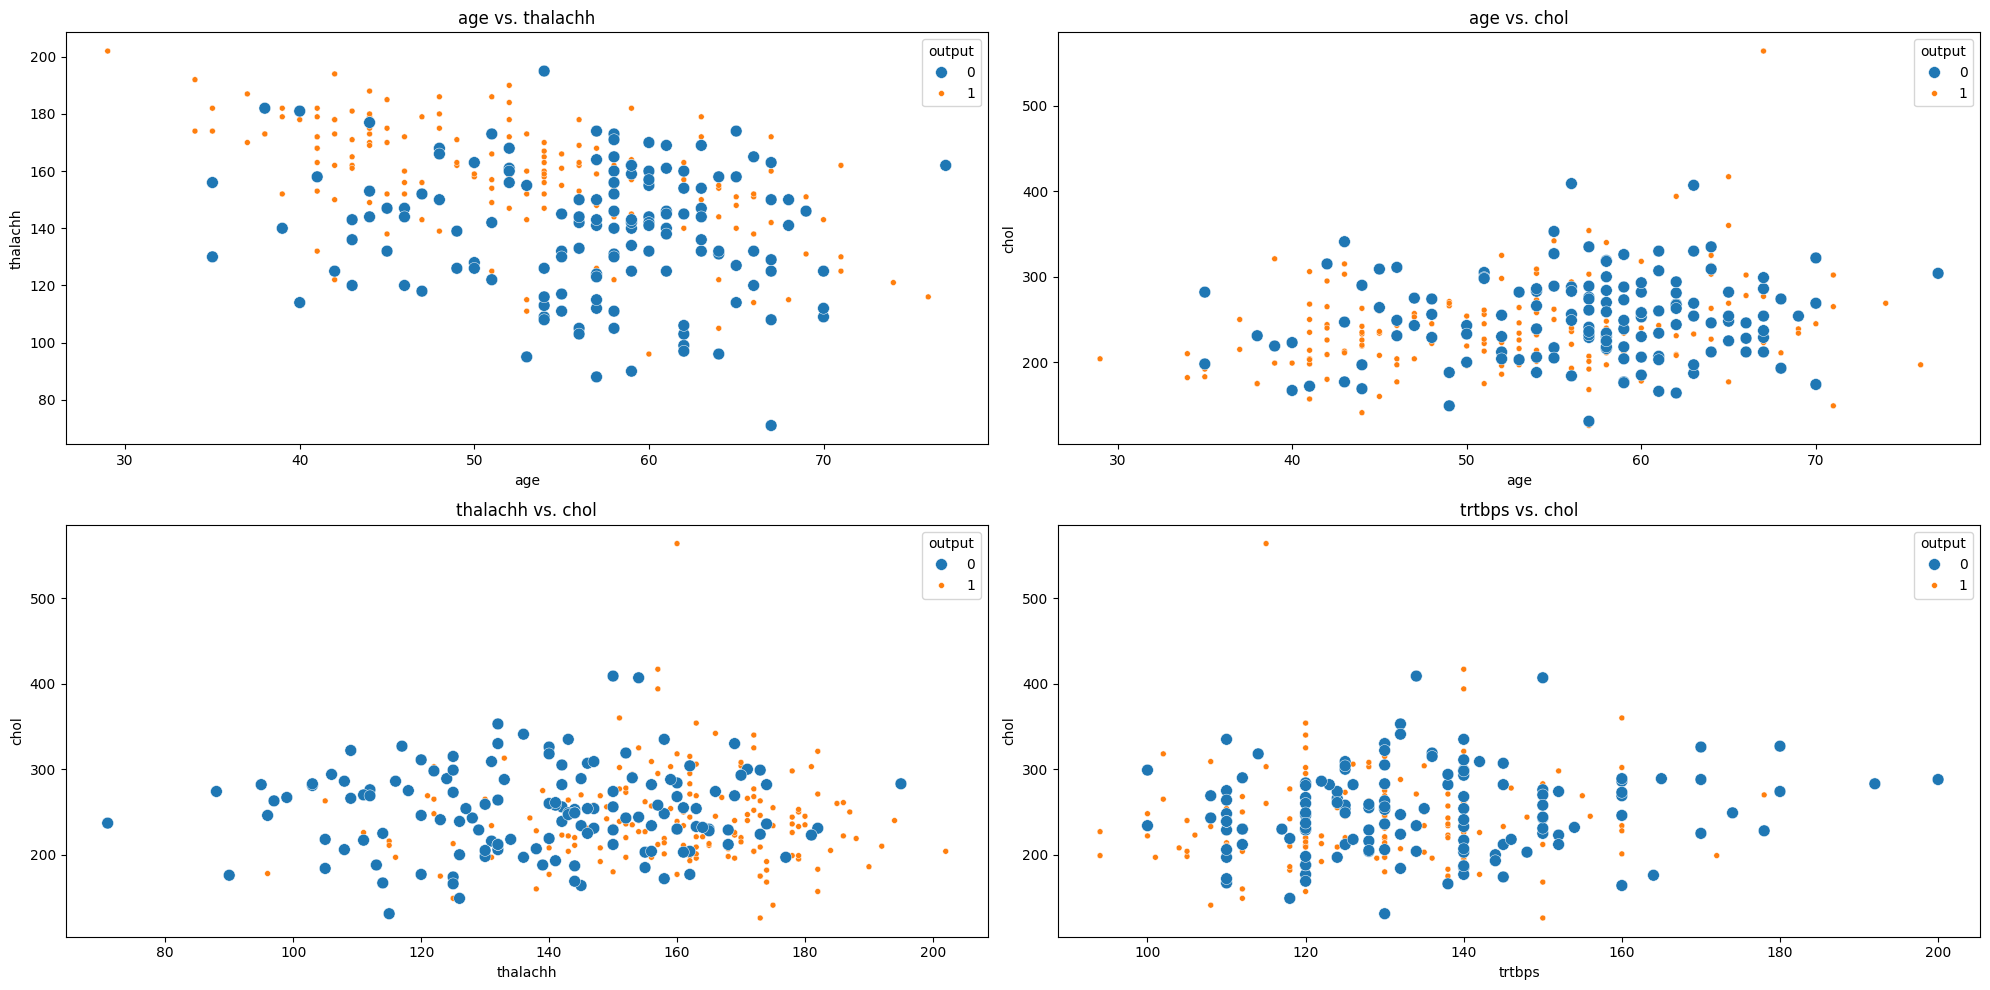

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
axes = axes.flatten()
scatter_pairs = [('age', 'thalachh'), ('age', 'chol'), ('thalachh', 'chol'), ('trtbps', 'chol')]
for i, (x_col, y_col) in enumerate(scatter_pairs):
    sns.scatterplot(x=x_col, y=y_col, hue='output', size='output', data=df, ax=axes[i])
    axes[i].set_title(f'{x_col} vs. {y_col}')
plt.tight_layout()
plt.show()

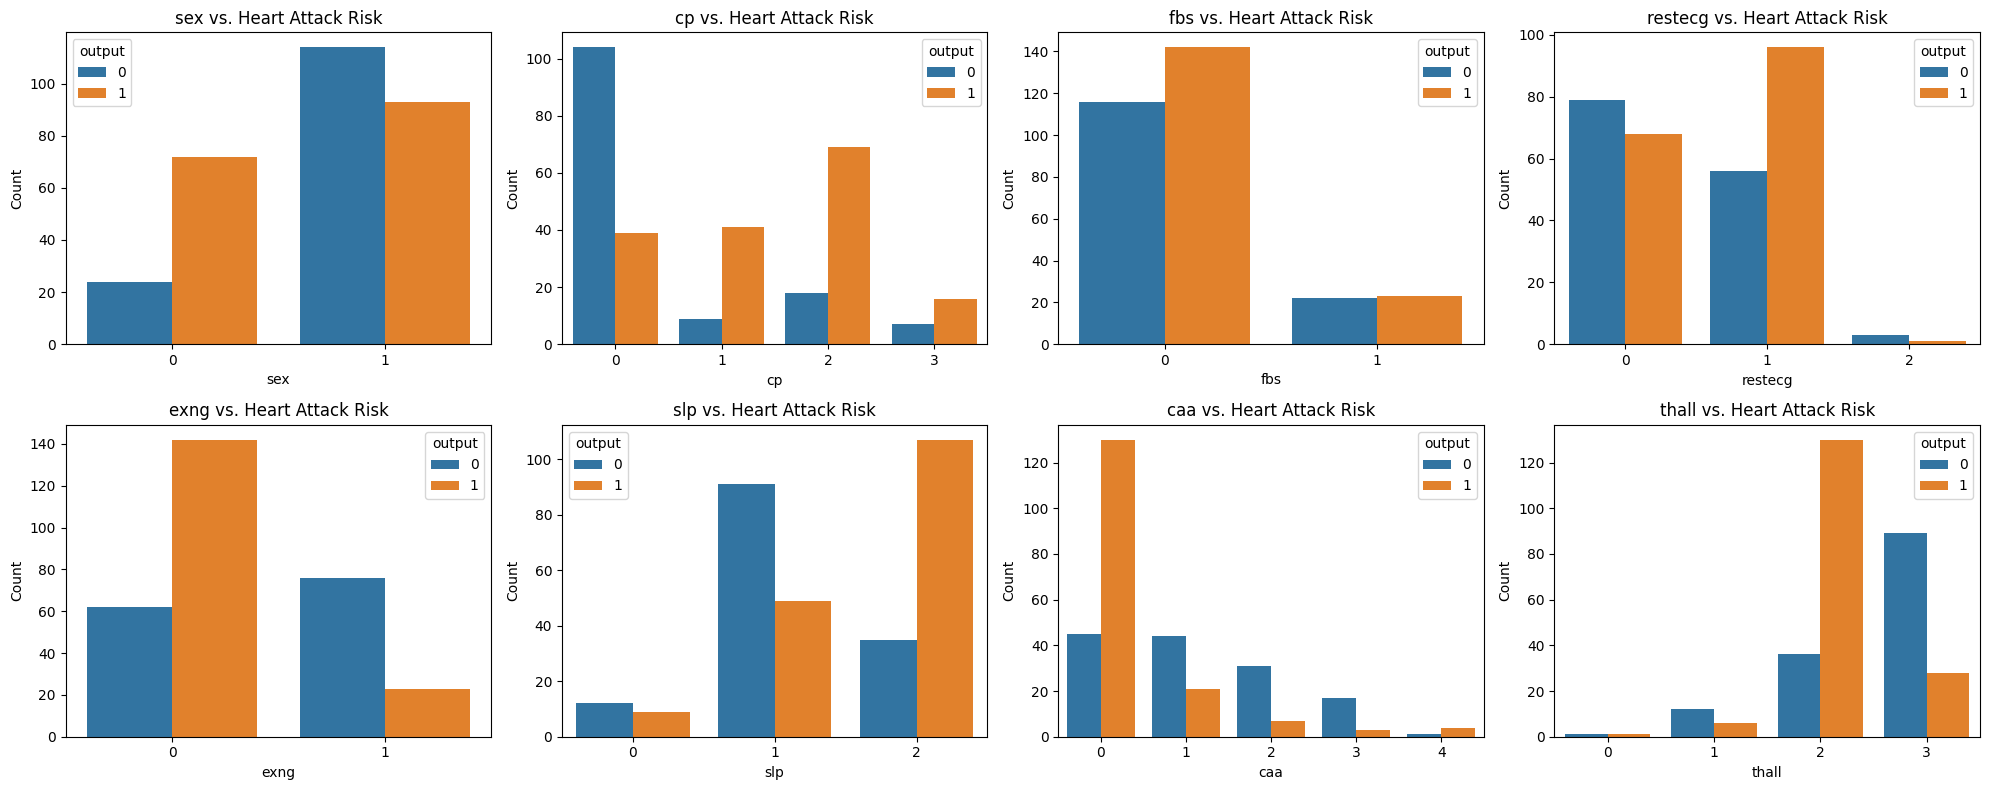

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 8))
axes = axes.flatten()
cat_cols = [col for col in categorical_cols if col != 'output']  # Exclude output itself
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='output', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs. Heart Attack Risk')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove empty subplots
plt.tight_layout()
plt.show()

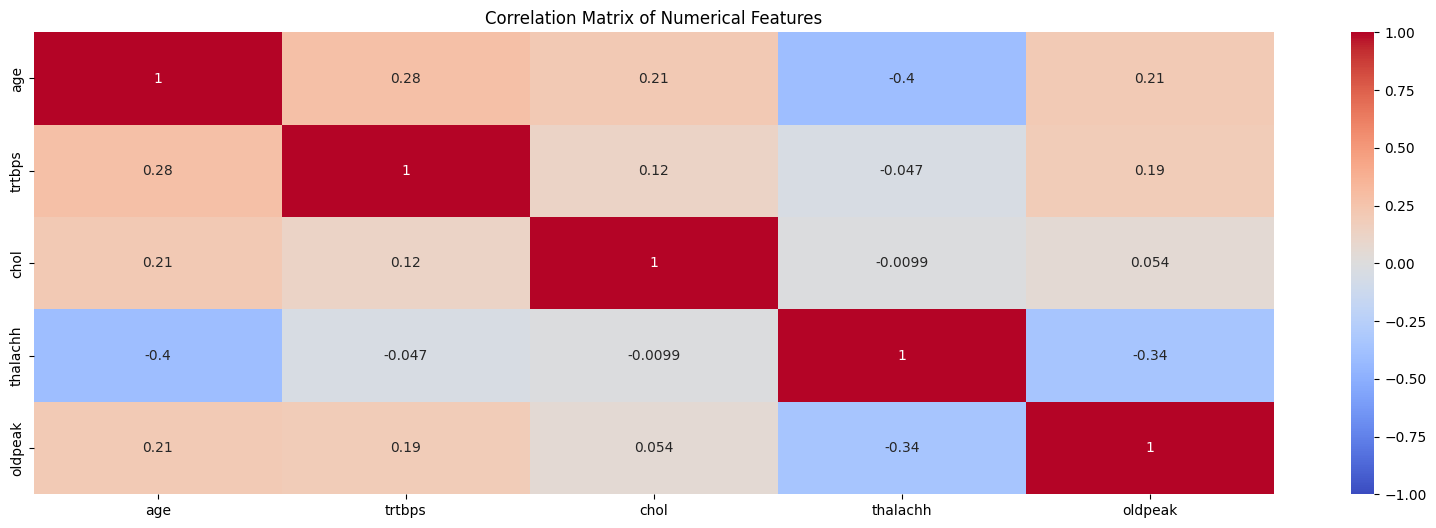

In [14]:
plt.figure(figsize=(20, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

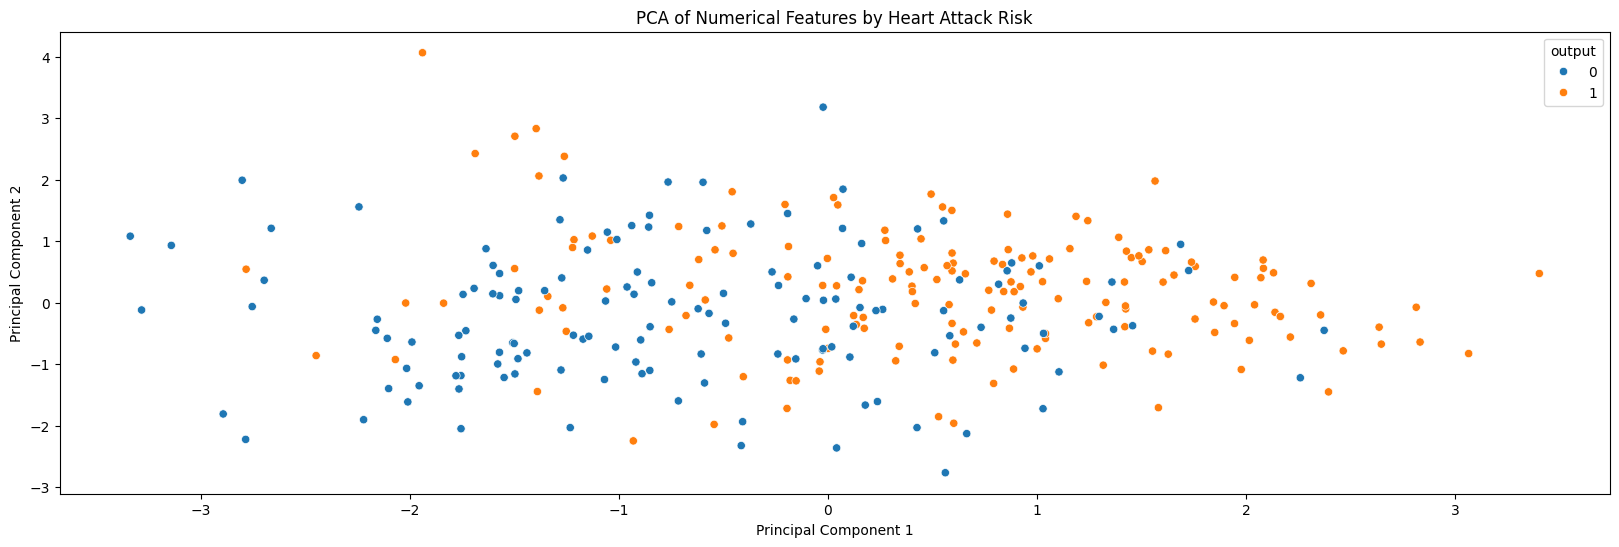

In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_cols])
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['output'] = df['output']

plt.figure(figsize=(20, 6))
sns.scatterplot(x='PC1', y='PC2', hue='output', data=pca_df)
plt.title('PCA of Numerical Features by Heart Attack Risk')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [16]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [17]:
import evalml

In [18]:
X=df.drop(columns=["output"],axis=1)
y=df["output"]

X_train,X_test,y_train,y_test=evalml.preprocessing.split_data(X,y,problem_type="binary",test_size=0.2)

In [19]:
from evalml.data_checks import DefaultDataChecks
from ipywidgets import widgets




data_checks = DefaultDataChecks("binary", "log loss binary")
data_checks.validate(X_train, y_train)


[]

In [20]:
automl = evalml.automl.AutoMLSearch(
    X_train=X_train,
    y_train=y_train,
    X_holdout=X_test,
    y_holdout=y_test,
    
    problem_type="binary",
    verbose=True,
)
automl.search(interactive_plot=False)

AutoMLSearch will use the holdout set to score and rank pipelines.
Using default limit of max_batches=2.


*****************************
* Beginning pipeline search *
*****************************

Optimizing for Log Loss Binary. 
Lower score is better.

Using SequentialEngine to train and score pipelines.
Searching up to 2 batches for a total of None pipelines. 
Allowed model families: 

Evaluating Baseline Pipeline: Mode Baseline Binary Classification Pipeline


INFO	evalml.automl.automl_search.verbose:automl_search.py:_add_baseline_pipelines()- Evaluating Baseline Pipeline: Mode Baseline Binary Classification Pipeline


Mode Baseline Binary Classification Pipeline:


INFO	evalml.automl.automl_search.verbose:engine_base.py:write_to_logger()- Mode Baseline Binary Classification Pipeline:


	Starting cross validation


...

Best pipeline: Logistic Regression Classifier w/ Label Encoder + Imputer + Standard Scaler + Select Columns Transformer


INFO	evalml.automl.automl_search.verbose:automl_search.py:search()- Best pipeline: Logistic Regression Classifier w/ Label Encoder + Imputer + Standard Scaler + Select Columns Transformer


Best pipeline Log Loss Binary: 0.453249


INFO	evalml.automl.automl_search.verbose:automl_search.py:search()- Best pipeline Log Loss Binary: 0.453249


{1: {'Random Forest Classifier w/ Label Encoder + Imputer + RF Classifier Select From Model': 3.657501459121704,
  'Total time of batch': 3.809954881668091},
 2: {'LightGBM Classifier w/ Label Encoder + Imputer + Select Columns Transformer': 2.0739784240722656,
  'Extra Trees Classifier w/ Label Encoder + Imputer + Select Columns Transformer': 2.4894535541534424,
  'Elastic Net Classifier w/ Label Encoder + Imputer + Standard Scaler + Select Columns Transformer': 1.8220441341400146,
  'XGBoost Classifier w/ Label Encoder + Imputer + Select Columns Transformer': 2.6957874298095703,
  'Logistic Regression Classifier w/ Label Encoder + Imputer + Standard Scaler + Select Columns Transformer': 6.937675714492798,
  'Total time of batch': 16.64048719406128}}

In [21]:
automl.rankings

,id,pipeline_name,search_order,ranking_score,holdout_score,mean_cv_score,standard_deviation_cv_score,percent_better_than_baseline,high_variance_cv,parameters
0,6,Logistic Regression Classifier w/ Label Encode...,6,0.453249,0.453249,0.519092,0.050908,96.831483,False,"{'Label Encoder': {'positive_label': None}, 'I..."
1,4,Elastic Net Classifier w/ Label Encoder + Impu...,4,0.453303,0.453303,0.519576,0.051693,96.828526,False,"{'Label Encoder': {'positive_label': None}, 'I..."
2,1,Random Forest Classifier w/ Label Encoder + Im...,1,0.484860,0.484860,0.466918,0.024541,97.149952,False,"{'Label Encoder': {'positive_label': None}, 'I..."
3,3,Extra Trees Classifier w/ Label Encoder + Impu...,3,0.494485,0.494485,0.438910,0.013250,97.320912,False,"{'Label Encoder': {'positive_label': None}, 'I..."
4,5,XGBoost Classifier w/ Label Encoder + Imputer ...,5,0.664453,0.664453,0.516731,0.064219,96.845894,False,"{'Label Encoder': {'positive_label': None}, 'I..."
5,2,LightGBM Classifier w/ Label Encoder + Imputer...,2,0.675349,0.675349,0.474832,0.020070,97.101643,False,"{'Label Encoder': {'positive_label': None}, 'I..."
6,0,Mode Baseline Binary Classification Pipeline,0,16.544628,16.544628,16.382805,0.141301,0.000000,False,"{'Label Encoder': {'positive_label': None}, 'B..."


In [22]:
automl.get_recommendation_scores(use_pipeline_names=True)

{'Baseline Classifier': 25.0,
 'Random Forest Classifier': 80.59770701341284,
 'LightGBM Classifier': 79.34767787136032,
 'Extra Trees Classifier': 82.64024748446663,
 'Elastic Net Classifier': 83.79825455575146,
 'XGBoost Classifier': 79.23135791592208,
 'Logistic Regression Classifier': 83.79833679480814}

In [23]:
automl.get_recommendation_scores(priority="F1", use_pipeline_names=True)

{'Baseline Classifier': 16.666666666666664,
 'Random Forest Classifier': 77.61240169053394,
 'LightGBM Classifier': 76.4881955039838,
 'Extra Trees Classifier': 80.09349832297774,
 'Elastic Net Classifier': 80.86550303716763,
 'XGBoost Classifier': 76.6304290868052,
 'Logistic Regression Classifier': 80.86555786320542}

In [24]:
evalml.objectives.get_default_recommendation_objectives("binary")

{'AUC', 'Balanced Accuracy Binary', 'F1', 'Log Loss Binary'}

In [26]:
best_pipeline=automl.best_pipeline
best_pipeline

pipeline = BinaryClassificationPipeline(component_graph={'Label Encoder': ['Label Encoder', 'X', 'y'], 'Imputer': ['Imputer', 'X', 'Label Encoder.y'], 'Standard Scaler': ['Standard Scaler', 'Imputer.x', 'Label Encoder.y'], 'Select Columns Transformer': ['Select Columns Transformer', 'Standard Scaler.x', 'Label Encoder.y'], 'Logistic Regression Classifier': ['Logistic Regression Classifier', 'Select Columns Transformer.x', 'Label Encoder.y']}, parameters={'Label Encoder':{'positive_label': None}, 'Imputer':{'categorical_impute_strategy': 'most_frequent', 'numeric_impute_strategy': 'mean', 'boolean_impute_strategy': 'most_frequent', 'categorical_fill_value': None, 'numeric_fill_value': None, 'boolean_fill_value': None}, 'Select Columns Transformer':{'columns': ['age', 'cp', 'chol', 'thalachh', 'exng', 'caa', 'thall']}, 'Logistic Regression Classifier':{'penalty': 'l2', 'C': 1.0, 'n_jobs': -1, 'multi_class': 'auto', 'solver': 'lbfgs'}}, random_seed=0)

In [28]:
automl_recommendation = evalml.automl.AutoMLSearch(
    X_train=X_train,
    y_train=y_train,
    X_holdout=X_test,
    y_holdout=y_test,
    problem_type="binary",
    use_recommendation=True,
)
automl_recommendation.search(interactive_plot=False)

automl_recommendation.rankings[
    [
        "id",
        "pipeline_name",
        "search_order",
        "recommendation_score",
        "holdout_score",
        "mean_cv_score",
    ]
]

,id,pipeline_name,search_order,recommendation_score,holdout_score,mean_cv_score
0,6,Logistic Regression Classifier w/ Label Encode...,6,83.798337,0.453249,0.519092
1,4,Elastic Net Classifier w/ Label Encoder + Impu...,4,83.798255,0.453303,0.519576
2,3,Extra Trees Classifier w/ Label Encoder + Impu...,3,82.640247,0.494485,0.438910
3,1,Random Forest Classifier w/ Label Encoder + Im...,1,80.597707,0.484860,0.466918
4,2,LightGBM Classifier w/ Label Encoder + Imputer...,2,79.347678,0.675349,0.474832
5,5,XGBoost Classifier w/ Label Encoder + Imputer ...,5,79.231358,0.664453,0.516731
6,0,Mode Baseline Binary Classification Pipeline,0,25.000000,16.544628,16.382805


In [35]:
automl_recommendation.get_recommendation_score_breakdown(3)

{'AUC': 0.8387445887445888,
 'F1': 0.75,
 'Balanced Accuracy Binary': 0.7467532467532467,
 'Log Loss Binary': 0.49448477835857263}

In [36]:
automl.describe_pipeline(1)


*****************************************************************************************


INFO	evalml.pipelines.pipeline_base.describe:logger.py:log_title()- 
*****************************************************************************************


* Random Forest Classifier w/ Label Encoder + Imputer + RF Classifier Select From Model *


INFO	evalml.pipelines.pipeline_base.describe:logger.py:log_title()- * Random Forest Classifier w/ Label Encoder + Imputer + RF Classifier Select From Model *


*****************************************************************************************


...

INFO	evalml.automl.automl_search.describe_pipeline:logger.py:log_subtitle()- Cross Validation


----------------


INFO	evalml.automl.automl_search.describe_pipeline:logger.py:log_subtitle()- ----------------


             Log Loss Binary  MCC Binary  Gini   AUC  Precision    F1  Balanced Accuracy Binary  Accuracy Binary # Training # Validation
0                      0.495       0.477 0.679 0.840      0.722 0.712                     0.738            0.741        161           81
1                      0.456       0.584 0.736 0.868      0.857 0.738                     0.779            0.790        161           81
2                      0.450       0.673 0.722 0.861      0.871 0.806                     0.830            0.838        162           80
mean                   0.467       0.578 0.712 0.856      0.817 0.752                     0.782            0.789          -            -
std                    0.025       0.098 0.029 0.015      0.082 0.048                     0.046            0.048          -            -
coef of var            0.053       0.170 0.041 0.017      0.101 0.064                     0.059            0.061          -            -


INFO	evalml.automl.automl_search.describe_pipeline:automl_search.py:describe_pipeline()-              Log Loss Binary  MCC Binary  Gini   AUC  Precision    F1  Balanced Accuracy Binary  Accuracy Binary # Training # Validation
0                      0.495       0.477 0.679 0.840      0.722 0.712                     0.738            0.741        161           81
1                      0.456       0.584 0.736 0.868      0.857 0.738                     0.779            0.790        161           81
2                      0.450       0.673 0.722 0.861      0.871 0.806                     0.830            0.838        162           80
mean                   0.467       0.578 0.712 0.856      0.817 0.752                     0.782            0.789          -            -
std                    0.025       0.098 0.029 0.015      0.082 0.048                     0.046            0.048          -            -
coef of var            0.053       0.170 0.041 0.017      0.101 0.064                    

In [37]:
pipeline = automl.get_pipeline(1)
print(pipeline.name)
print(pipeline.parameters)

Random Forest Classifier w/ Label Encoder + Imputer + RF Classifier Select From Model
{'Label Encoder': {'positive_label': None}, 'Imputer': {'categorical_impute_strategy': 'most_frequent', 'numeric_impute_strategy': 'mean', 'boolean_impute_strategy': 'most_frequent', 'categorical_fill_value': None, 'numeric_fill_value': None, 'boolean_fill_value': None}, 'RF Classifier Select From Model': {'number_features': None, 'n_estimators': 10, 'max_depth': None, 'percent_features': 0.5, 'threshold': 'median', 'n_jobs': -1}, 'Random Forest Classifier': {'n_estimators': 100, 'max_depth': 6, 'n_jobs': -1}}


In [38]:
best_pipeline = automl.best_pipeline
print(best_pipeline.name)
print(best_pipeline.parameters)
best_pipeline.predict(X_train)

Logistic Regression Classifier w/ Label Encoder + Imputer + Standard Scaler + Select Columns Transformer
{'Label Encoder': {'positive_label': None}, 'Imputer': {'categorical_impute_strategy': 'most_frequent', 'numeric_impute_strategy': 'mean', 'boolean_impute_strategy': 'most_frequent', 'categorical_fill_value': None, 'numeric_fill_value': None, 'boolean_fill_value': None}, 'Select Columns Transformer': {'columns': ['age', 'cp', 'chol', 'thalachh', 'exng', 'caa', 'thall']}, 'Logistic Regression Classifier': {'penalty': 'l2', 'C': 1.0, 'n_jobs': -1, 'multi_class': 'auto', 'solver': 'lbfgs'}}


269    0
191    0
15     1
224    0
250    0
      ..
142    1
33     1
181    0
262    0
54     1
Name: output, Length: 242, dtype: int64

In [41]:
evalml.objectives.get_all_objective_names()

['expvariance',
 'maxerror',
 'medianae',
 'mse',
 'mae',
 'r2',
 'mean squared log error',
 'root mean squared log error',
 'root mean squared error',
 'symmetric mean absolute percentage error',
 'mean absolute percentage error',
 'mean absolute scaled error',
 'mcc multiclass',
 'log loss multiclass',
 'auc weighted',
 'auc macro',
 'auc micro',
 'recall weighted',
 'recall macro',
 'recall micro',
 'precision weighted',
 'precision macro',
 'precision micro',
 'f1 weighted',
 'f1 macro',
 'f1 micro',
 'balanced accuracy multiclass',
 'accuracy multiclass',
 'mcc binary',
 'log loss binary',
 'gini',
 'auc',
 'recall',
 'precision',
 'f1',
 'balanced accuracy binary',
 'accuracy binary',
 'sensitivity at low alert rates',
 'lead scoring',
 'fraud cost',
 'cost benefit matrix']

In [43]:


best_pipeline.score(
    X_test, 
    y_test, 
    objectives=["auc", "f1", "precision", "recall", "log loss binary"]
)


OrderedDict([('AUC', 0.8603896103896104),
             ('F1', 0.8115942028985508),
             ('Precision', 0.7777777777777778),
             ('Recall', 0.8484848484848485),
             ('Log Loss Binary', 0.4512471855360593)])

In [46]:
automl_auc = evalml.automl.AutoMLSearch(
    X_train=X_train,
    y_train=y_train,
    problem_type='binary',
    objective='auc',
    additional_objectives=['f1', 'precision'],
    max_batches=1,
    optimize_thresholds=True
)

automl_auc.search()

{1: {'Random Forest Classifier w/ Label Encoder + Imputer + RF Classifier Select From Model': 2.514136552810669,
  'Total time of batch': 2.6380016803741455}}

In [47]:
automl_auc.rankings

,id,pipeline_name,search_order,ranking_score,mean_cv_score,standard_deviation_cv_score,percent_better_than_baseline,high_variance_cv,parameters
0,1,Random Forest Classifier w/ Label Encoder + Im...,1,0.856243,0.856243,0.014743,35.624261,False,"{'Label Encoder': {'positive_label': None}, 'I..."
1,0,Mode Baseline Binary Classification Pipeline,0,0.500000,0.500000,0.000000,0.000000,False,"{'Label Encoder': {'positive_label': None}, 'B..."


In [48]:
automl.describe_pipeline(1)


*****************************************************************************************


INFO	evalml.pipelines.pipeline_base.describe:logger.py:log_title()- 
*****************************************************************************************


* Random Forest Classifier w/ Label Encoder + Imputer + RF Classifier Select From Model *


INFO	evalml.pipelines.pipeline_base.describe:logger.py:log_title()- * Random Forest Classifier w/ Label Encoder + Imputer + RF Classifier Select From Model *


*****************************************************************************************


...

INFO	evalml.automl.automl_search.describe_pipeline:logger.py:log_subtitle()- Cross Validation


----------------


INFO	evalml.automl.automl_search.describe_pipeline:logger.py:log_subtitle()- ----------------


             Log Loss Binary  MCC Binary  Gini   AUC  Precision    F1  Balanced Accuracy Binary  Accuracy Binary # Training # Validation
0                      0.495       0.477 0.679 0.840      0.722 0.712                     0.738            0.741        161           81
1                      0.456       0.584 0.736 0.868      0.857 0.738                     0.779            0.790        161           81
2                      0.450       0.673 0.722 0.861      0.871 0.806                     0.830            0.838        162           80
mean                   0.467       0.578 0.712 0.856      0.817 0.752                     0.782            0.789          -            -
std                    0.025       0.098 0.029 0.015      0.082 0.048                     0.046            0.048          -            -
coef of var            0.053       0.170 0.041 0.017      0.101 0.064                     0.059            0.061          -            -


INFO	evalml.automl.automl_search.describe_pipeline:automl_search.py:describe_pipeline()-              Log Loss Binary  MCC Binary  Gini   AUC  Precision    F1  Balanced Accuracy Binary  Accuracy Binary # Training # Validation
0                      0.495       0.477 0.679 0.840      0.722 0.712                     0.738            0.741        161           81
1                      0.456       0.584 0.736 0.868      0.857 0.738                     0.779            0.790        161           81
2                      0.450       0.673 0.722 0.861      0.871 0.806                     0.830            0.838        162           80
mean                   0.467       0.578 0.712 0.856      0.817 0.752                     0.782            0.789          -            -
std                    0.025       0.098 0.029 0.015      0.082 0.048                     0.046            0.048          -            -
coef of var            0.053       0.170 0.041 0.017      0.101 0.064                    

In [49]:
best_pipeline_auc = automl_auc.best_pipeline

In [50]:
best_pipeline_auc.score(X_test, y_test,  objectives=["auc"])

OrderedDict([('AUC', 0.8354978354978355)])

In [51]:
automl_auc.save("automl.cloudpickle")

In [52]:
best_pipeline_auc.save("best_pipeline_auc.pkl")


In [55]:


loaded_pipeline = automl.load("best_pipeline_auc.pkl")

In [57]:
loaded_pipeline.predict_proba(X_test)

,0,1
24,0.451291,0.548709
67,0.066980,0.933020
13,0.384479,0.615521
112,0.615960,0.384040
80,0.013493,0.986507
...,...,...
160,0.170241,0.829759
234,0.441435,0.558565
110,0.622799,0.377201
190,0.962571,0.037429


In [61]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    fbeta_score,
    precision_recall_curve,
    average_precision_score
)



y_pred=loaded_pipeline.predict(X_test)

confusion_matrix(y_test,y_pred)


array([[19,  9],
       [ 5, 28]], dtype=int64)

In [63]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.68      0.73        28
           1       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61

